Load Model 

In [ ]:
from Models.model import custom_model
import torch
from dataloader import create_dataset, get_transforms
from utils import get_mean_std, SquarePadding
from torchvision import transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

maxVIT = custom_model('maxvit_t', 1758)
maxVIT.load_state_dict(torch.load("checkpoints/maxvit_best.pth"))


/home/amo/miniconda3/envs/maxvit/lib/python3.10/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


model created


/tmp/ipykernel_3627869/3973410594.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  maxVIT.load_state_dict(torch.load("checkpoints/maxvit_epoch_150.pth"))


<All keys matched successfully>

In [13]:
maxVIT.eval()
maxVIT.to(device)

print(maxVIT.classifier)

maxVIT.classifier = torch.nn.Sequential(
    maxVIT.classifier[0],
    maxVIT.classifier[1],
    maxVIT.classifier[2],
    maxVIT.classifier[3],
    maxVIT.classifier[4],
)

print(maxVIT.classifier)

Sequential(
  (0): AdaptiveAvgPool2d(output_size=1)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): Tanh()
  (5): Linear(in_features=512, out_features=1758, bias=True)
)
Sequential(
  (0): AdaptiveAvgPool2d(output_size=1)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): Tanh()
)


The dataset

In [14]:
mean = [0.9323, 0.9146, 0.8900]
std = [0.1745, 0.2119, 0.2638]

transform = transforms.Compose([
    SquarePadding(),
    transforms.Resize((224, 224)),
    transforms.CenterCrop((224, 224)),
    transforms.Normalize(mean, std),
])
    

In [15]:
the_dataset =  create_dataset("Classifiction_dataset/train_standardized.csv", "Classifiction_dataset/Train", transform)

/home/amo/Projects/MaxVIT_Experiment/dataloader.py:13: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  self.fishes = pd.read_csv(csv_file)


In [36]:
embedding_dataloader = DataLoader(the_dataset, batch_size=32, shuffle=False, num_workers=0)

In [40]:
embeddings = []
labels = []
paths = []

with torch.no_grad():
    for i_batch, batch in enumerate(embedding_dataloader):
        images, ids, path = batch['image'].to(device), batch['species_id'], batch['img_name']

        the_embeddings = maxVIT(images)
        the_embeddings = the_embeddings.cpu()
        embeddings.append(the_embeddings)
        labels.append(ids)
        paths.append(path)


In [42]:
torch.save({
    "embeddings": embeddings,
    "labels": labels,
    "paths" : paths
}, "embeddings.pt")

Plotting

In [3]:
import itertools
import torch.nn.functional as F


data = torch.load("Embeddings/embeddings.pt")

embd = torch.cat(data['embeddings'], dim = 0)
embd = F.normalize(embd, dim=1)
thelabels = torch.cat(data['labels'], dim = 0)
thepaths = data['paths']
flat_list = list(itertools.chain.from_iterable(thepaths))

print(len(thelabels))
print(len(flat_list))
print(embd[0])

39800
39800
tensor([ 0.0460, -0.0454, -0.0519, -0.0450,  0.0324, -0.0534,  0.0415, -0.0390,
         0.0546, -0.0350, -0.0498, -0.0549,  0.0493,  0.0304,  0.0210, -0.0509,
         0.0365,  0.0522, -0.0210,  0.0521,  0.0097, -0.0010, -0.0276, -0.0413,
        -0.0368, -0.0056, -0.0546, -0.0495, -0.0095, -0.0209,  0.0496,  0.0440,
        -0.0553,  0.0387, -0.0494, -0.0164, -0.0427,  0.0547,  0.0527,  0.0536,
        -0.0426,  0.0541,  0.0498,  0.0552, -0.0544, -0.0532, -0.0408, -0.0505,
        -0.0167, -0.0506,  0.0389, -0.0229, -0.0209,  0.0067, -0.0058,  0.0547,
         0.0014, -0.0176, -0.0411,  0.0270,  0.0545, -0.0527,  0.0547,  0.0515,
        -0.0526,  0.0490, -0.0499, -0.0057,  0.0500,  0.0279, -0.0182, -0.0316,
         0.0438,  0.0159,  0.0501, -0.0498,  0.0275,  0.0315,  0.0545, -0.0008,
        -0.0375, -0.0553,  0.0181,  0.0500, -0.0340,  0.0334,  0.0040,  0.0545,
        -0.0354, -0.0552,  0.0208,  0.0540,  0.0552,  0.0255,  0.0547, -0.0550,
         0.0326,  0.0528,  0

/tmp/ipykernel_3627869/3383065220.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("Embeddings/embeddings.pt")


In [43]:
thelabels_lst = thelabels.tolist()
n_unique = len(list(set(thelabels_lst)))
embd_avg = []
new_labels = []

print(n_unique)

for i in range(n_unique):
    embdlst = []
    
    for index, label in enumerate(thelabels_lst):
        if i == label:
            embdlst.append(embd[index])
    
    mean_tensor = torch.mean(torch.stack(embdlst), dim=0)
    embd_avg.append(mean_tensor)
    new_labels.append(i)

embd_avg = torch.stack(embd_avg)


1758


In [74]:
query = embd_avg[1].unsqueeze(0)

similarity = torch.mm(query, embd_avg.T)
topk = similarity.topk(10)
indices = topk.indices.squeeze()
indices = indices.tolist()

print(indices)

[1, 642, 73, 5, 48, 55, 1682, 955, 188, 138]


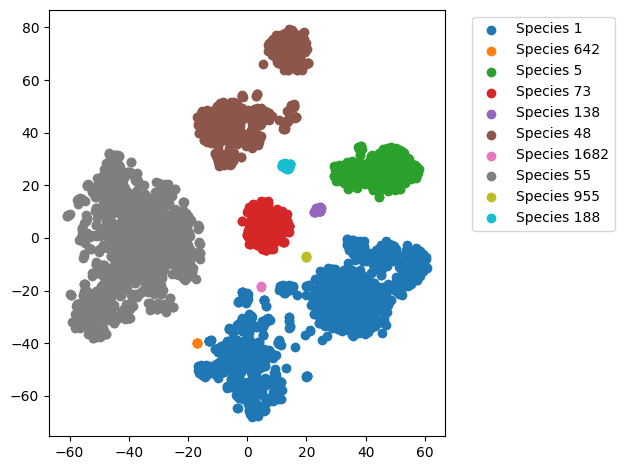

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np


img_embds = []
track = []

for i in indices:
    for index, label in enumerate(thelabels_lst):
        if i == label:
            img_embds.append(embd[index])
            track.append(label)
    

img_embds = torch.stack(img_embds)

tsne = TSNE(n_components=2)
reduced = tsne.fit_transform(img_embds.numpy())


# get unique species (top 10)
unique_species = list(set(track))

# map each species → 0..9
species_to_idx = {species: i for i, species in enumerate(unique_species)}

# remap labels
track_mapped = [species_to_idx[s] for s in track]

for species, idx in species_to_idx.items():
    mask = np.array(track_mapped) == idx
    plt.scatter(
        reduced[mask, 0],
        reduced[mask, 1],
        label=f"Species {species}"
    )

plt.legend(
    bbox_to_anchor=(1.05, 1),  # move it outside
    loc='upper left',
    fontsize=10
)

plt.tight_layout()
plt.show()